In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from paths import *
from reshandler import DictResHandler

In [24]:
def plot_many_matplotlib_errbar(arrs, labels, save_path, plot_label_dict=None, y_range=None):
    """
    Plots a bar plot with error bars using matplotlib, with labels as the x-axis.

    Parameters:
    - arrs: List of 2D arrays, where each array is (num_samples, num_steps).
    - labels: List of labels for each dataset.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Labels", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    mean_values = []
    ci_95s = []
    
    # Calculate means and confidence intervals for each label
    for arr in arrs:
        mean_val = np.mean(arr)
        sem_val = stats.sem(arr.flatten())
        ci_95 = 1.96 * sem_val  # 95% confidence interval
        mean_values.append(mean_val)
        ci_95s.append(ci_95)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = np.arange(len(labels))
    
    # Plot bars with error bars
    ax.bar(x_positions, mean_values, yerr=ci_95s, alpha=0.8, capsize=5, color='skyblue', edgecolor='black')
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=75)
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()



def plot_grouped_bar_errbar(arrs_list, labels, save_path, test_names, plot_label_dict=None, y_range=None):
    """
    Plots grouped bar plots with error bars for multiple tests.

    Parameters:
    - arrs_list: List of lists of 2D arrays. Each inner list contains results for one test across different layers.
    - labels: List of layer names.
    - save_path: Path to save the resulting plot image.
    - test_names: List of test names, corresponding to arrs_list.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Layers", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    num_tests = len(arrs_list)
    num_layers = len(labels)
    bar_width = 0.2  # Width of each bar
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_tests))  # Generate distinct colors

    # Compute mean values and confidence intervals
    mean_values = []
    ci_95s = []
    
    for test_arrs in arrs_list:
        test_means = []
        test_cis = []
        for arr in test_arrs:
            mean_val = np.mean(arr)
            sem_val = stats.sem(arr.flatten())
            ci_95 = 1.96 * sem_val  # 95% confidence interval
            test_means.append(mean_val)
            test_cis.append(ci_95)
        mean_values.append(test_means)
        ci_95s.append(test_cis)

    # Plot grouped bars
    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = np.arange(num_layers)

    for i, (means, cis, color, test_name) in enumerate(zip(mean_values, ci_95s, colors, test_names)):
        ax.bar(x_positions + i * bar_width, means, yerr=cis, capsize=5, 
               width=bar_width, color=color, edgecolor='black', label=test_name, alpha=0.8)

    # Customize plot
    ax.set_xticks(x_positions + (num_tests - 1) * bar_width / 2)
    ax.set_xticklabels(labels, rotation=75)
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    ax.legend()

    if y_range:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


import textwrap

def wrap_labels(labels, max_width=10):
    """Wraps long labels to fit within a given width."""
    return ['\n'.join(textwrap.wrap(label, max_width)) for label in labels]

def plot_grouped_bar_errbar_wrap(arrs_list, labels, save_path, test_names, plot_label_dict=None, y_range=None):
    """
    Plots grouped bar plots with error bars for multiple tests.

    Parameters:
    - arrs_list: List of lists of 2D arrays. Each inner list contains results for one test across different layers.
    - labels: List of layer names.
    - save_path: Path to save the resulting plot image.
    - test_names: List of test names, corresponding to arrs_list.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Layers", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    num_tests = len(arrs_list)
    num_layers = len(labels)
    bar_width = 0.2  # Width of each bar
    # colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_tests))  # Generate distinct colors
    colors = ["#1a80bb", "#ea801c"]

    # Compute mean values and confidence intervals
    mean_values = []
    ci_95s = []
    
    for test_arrs in arrs_list:
        test_means = []
        test_cis = []
        for arr in test_arrs:
            mean_val = np.mean(arr)
            sem_val = stats.sem(arr.flatten())
            ci_95 = 1.96 * sem_val  # 95% confidence interval
            test_means.append(mean_val)
            test_cis.append(ci_95)
        mean_values.append(test_means)
        ci_95s.append(test_cis)

    # Plot grouped bars
    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = np.arange(num_layers)

    for i, (means, cis, color, test_name) in enumerate(zip(mean_values, ci_95s, colors, test_names)):
        ax.bar(x_positions + i * bar_width, means, yerr=cis, capsize=5, 
               width=bar_width, color=color, edgecolor='black', label=test_name, alpha=0.8)

    # Customize plot
    ax.set_xticks(x_positions + (num_tests - 1) * bar_width / 2)
    ax.set_xticklabels(wrap_labels(labels, max_width=11), rotation=0, ha="center")

    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    ax.legend()

    if y_range:
        ax.set_ylim(y_range)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


## Configurations

In [4]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
dim = 16
balance_type = "b"
strseq_learned_runs = "12345"
test_name_pos = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
test_name_cat = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
test_plot_name_pos = "Phoneme Position Test"
test_plot_name_cat = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
# test_plot_name = ""
model_name = f"recon{dim}-phi"
res_save_dir = os.path.join(eval_dir, f"PLOTS_20250208")
mk(res_save_dir)
sample_epoch_start = 95
sample_epoch_end = 100
ori_wise = False

## Draw End Epochs

### Collect Pos Data

In [8]:
layered_res_pos = {}
look_for_layer_path = test_name_pos.split("-")[0] + "-" + test_name_pos.split("-")[1] + "-" + test_name_pos.split("-")[2] + "-" + test_name_pos.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_pos[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_pos["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

# to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
#                 "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
#                 "enc-rnn5-f", 
#                 "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
to_plot_key_order = ["ori", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f", 
                "attnout"]
to_plot_name_order = ["input-mel-spectrogram", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output", 
                "cross-attention-output"]
reordered_values = [layered_res_pos[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
# plot_many_matplotlib_errbar(reordered_values, to_plot_name_order, 
#             os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name_pos}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
#             plot_label_dict={"xlabel": "Intermediate Layers", 
#                              "ylabel": y_label_name, 
#                              "title": f"Intermediate Representation ABX Performance on {test_plot_name_pos} during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
#             )   # y_range=(0, 0.5)
# print("Done.")
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean()  # Mean over trials
    std_values = array.std()   # Standard deviation over trials

    print(f"{layer_name}: {mean_values:.3f}; SD = {std_values:.3f}")

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...
ori: 0.482; SD = 0.023
enc-rnn1-f: 0.491; SD = 0.016
enc-rnn5-f: 0.098; SD = 0.041
enc-rnn1-b: 0.488; SD = 0.018
enc-rnn5-b: 0.476; SD = 0.026
hidrep: 0.105; SD = 0.048
dec-rnn1-f: 0.382; SD = 0.112
dec-rnn5-f: 0.092; SD = 0.040
attnout: 0.485; SD = 0.020


In [10]:
layered_res_cat = {}
look_for_layer_path = test_name_cat.split("-")[0] + "-" + test_name_cat.split("-")[1] + "-" + test_name_cat.split("-")[2] + "-" + test_name_cat.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res_cat[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res_cat["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

# to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
#                 "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
#                 "enc-rnn5-f", 
#                 "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
to_plot_key_order = ["ori", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f", 
                "attnout"]
to_plot_name_order = ["input-mel-spectrogram", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output", 
                "cross-attention-output"]
reordered_values = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean()  # Mean over trials
    std_values = array.std()   # Standard deviation over trials

    print(f"{layer_name}: {mean_values:.3f}; SD = {std_values:.3f}")

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...
ori: 0.177; SD = 0.043
enc-rnn1-f: 0.368; SD = 0.050
enc-rnn5-f: 0.476; SD = 0.035
enc-rnn1-b: 0.307; SD = 0.050
enc-rnn5-b: 0.183; SD = 0.063
hidrep: 0.303; SD = 0.045
dec-rnn1-f: 0.371; SD = 0.055
dec-rnn5-f: 0.493; SD = 0.026
attnout: 0.125; SD = 0.046


### Plot Input Mel  Spectrogram

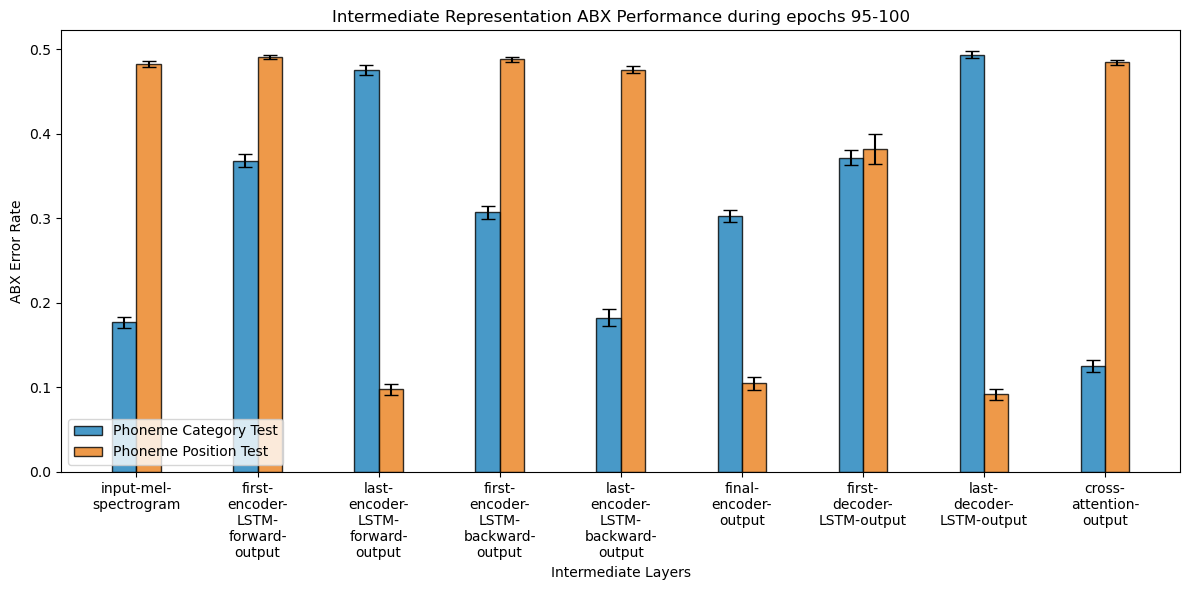

In [25]:
to_plot_key_order = ["ori", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f", 
                "attnout"]
to_plot_name_order = ["input-mel-spectrogram", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output", 
                "cross-attention-output"]

reordered_values_pos = [layered_res_pos[key] for key in to_plot_key_order]
reordered_values_cat = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"

plot_grouped_bar_errbar_wrap([reordered_values_cat, reordered_values_pos], to_plot_name_order, 
            os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-catpos-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
            [f"{test_plot_name_cat}", f"{test_plot_name_pos}"], 
            plot_label_dict={"xlabel": "Intermediate Layers", 
                             "ylabel": y_label_name, 
                             "title": f"Intermediate Representation ABX Performance during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
            )

In [ ]:
to_plot_key_order = ["ori", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f", 
                "attnout"]
to_plot_name_order = ["input-mel-spectrogram", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output", 
                "cross-attention-output"]

reordered_values_pos = [layered_res_pos[key] for key in to_plot_key_order]
reordered_values_cat = [layered_res_cat[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"

plot_grouped_bar_errbar([reordered_values_cat, reordered_values_pos], to_plot_name_order, 
            os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-catpos-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
            [f"{test_plot_name_cat}", f"{test_plot_name_pos}"], 
            plot_label_dict={"xlabel": "Intermediate Layers", 
                             "ylabel": y_label_name, 
                             "title": f"Intermediate Representation ABX Performance during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
            )

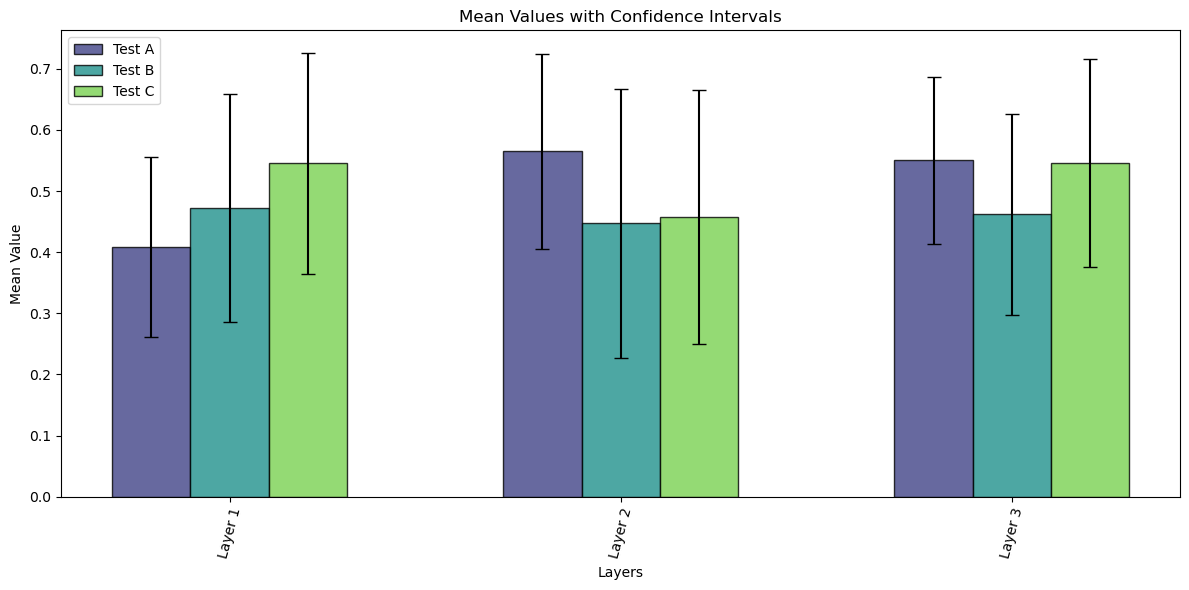

In [12]:
# Assume arrs_list contains three sets of test results for three layers
test_results_1 = [np.random.rand(10, 1) for _ in range(3)]  # Test 1 for 3 layers
test_results_2 = [np.random.rand(10, 1) for _ in range(3)]  # Test 2 for 3 layers
test_results_3 = [np.random.rand(10, 1) for _ in range(3)]  # Test 3 for 3 layers

arrs_list = [test_results_1, test_results_2, test_results_3]
labels = ["Layer 1", "Layer 2", "Layer 3"]
test_names = ["Test A", "Test B", "Test C"]
save_path = "grouped_bar_plot.png"

plot_grouped_bar_errbar(arrs_list, labels, save_path, test_names)


## Plot Trajectory

In [26]:
def plot_many_matplotlib(arrs, labels, save_path, plot_label_dict=None, y_range=None, cloud=True):
    """
    Plots the relation between epoch and ABX error rate using matplotlib.

    Parameters:
    - arrs: List of 2D arrays (num_samples, num_epochs).
    - labels: List of labels for the trajectories.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    - cloud: If True, shows confidence interval shading.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Epoch", "ylabel": "ABX Error Rate", "title": "ABX Error Rate Across Epochs"}

    n_steps = arrs[0].shape[1]
    mean_trajs = []
    lower_bounds = []
    upper_bounds = []

    # Calculate means and confidence intervals
    for arr in arrs:
        assert arr.shape[1] == n_steps
        mean_traj = np.mean(arr, axis=0)
        sem_arr = stats.sem(arr, axis=0)
        ci_95 = 1.96 * sem_arr  # 95% confidence interval
        upper_bound = mean_traj + ci_95
        lower_bound = mean_traj - ci_95
        mean_trajs.append(mean_traj)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = np.arange(n_steps)

    for idx, (mean_traj, lower_bound, upper_bound, label) in enumerate(zip(mean_trajs, lower_bounds, upper_bounds, labels)):
        if cloud:
            # Confidence interval shading
            ax.fill_between(
                epochs,
                lower_bound,
                upper_bound,
                color=f"C{idx}",
                alpha=0.2,
                label=None  # Label CI once
            )
        # Mean trajectory
        ax.plot(
            epochs,
            mean_traj,
            label=label,
            color=f"C{idx}",
            linewidth=2
        )

    # Customize plot
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    # Set legend outside the plot
    # ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    ax.legend(
        loc='upper center',    # Base location at the top-center
        bbox_to_anchor=(0.5, -0.15),  # Shift 0.15 below the axis
        ncol=2,               # Number of columns for legend entries
        frameon=False         # Optional: Remove legend frame
    )
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    # Adjust layout to make room for the legend
    # plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for the legend
    plt.subplots_adjust(bottom=0.2)
    plt.savefig(save_path)
    plt.show()


In [35]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
dim = 16
balance_type = "b"
strseq_learned_runs = "12345"
test_name = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
# test_name = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
test_plot_name = "Phoneme Position Test"
# test_plot_name = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
# test_plot_name = ""
model_name = f"recon{dim}-phi"
res_save_dir = os.path.join(eval_dir, f"PLOTS_20250208")
mk(res_save_dir)
sample_epoch_start = 0
sample_epoch_end = 101
ori_wise = False

## Draw End Epochs

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...


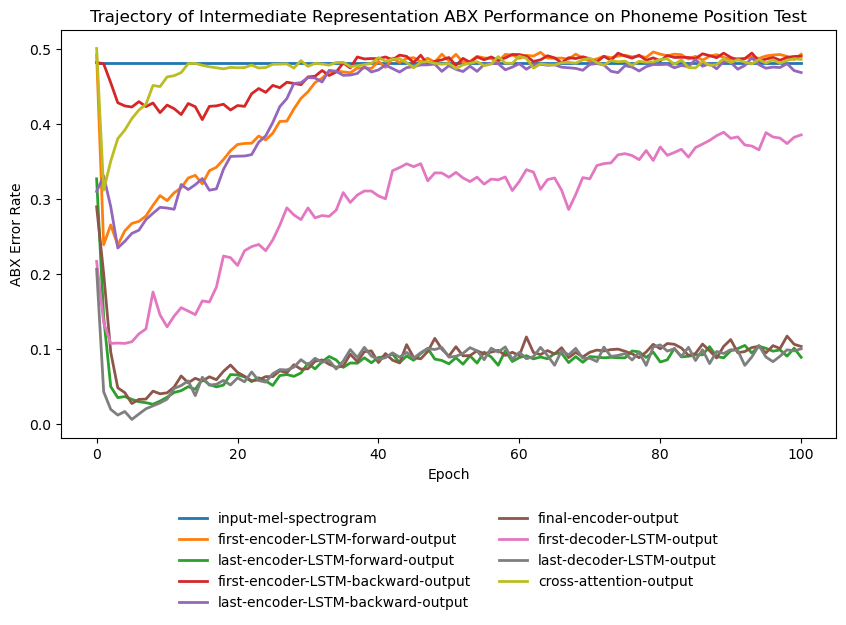

Done.


In [36]:
layered_res = {}
look_for_layer_path = test_name.split("-")[0] + "-" + test_name.split("-")[1] + "-" + test_name.split("-")[2] + "-" + test_name.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
    ori_res = np.full_like(ori_res, ori_res.mean(axis=1, keepdims=True))
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

# to_plot_key_order = ["attnout",  "enc-lin1", "dec-lin1", 
#                 "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
#                 "enc-rnn5-f", 
#                 "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", 
#                 "dec-rnn5-f"]
to_plot_key_order = ["ori", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f", 
                "attnout"]
to_plot_name_order = ["input-mel-spectrogram", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output", 
                "cross-attention-output"]
reordered_values = [layered_res[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
plot_many_matplotlib(reordered_values, to_plot_name_order, 
            os.path.join(res_save_dir, f"09-traj-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
            plot_label_dict={"xlabel": "Epoch", 
                             "ylabel": y_label_name, 
                             "title": f"Trajectory of Intermediate Representation ABX Performance on {test_plot_name}"}, 
            cloud=False
            )   # y_range=(0, 0.5)
print("Done.")

In [35]:
reordered_values[0].shape

(30, 101)

In [36]:
import pandas as pd
import numpy as np
# Create a list of dictionaries for the DataFrame
data = []
for layer_name, array in zip(to_plot_key_order, reordered_values):
    # Summarize over trials (axis 0)
    mean_values = array.mean(axis=0)  # Mean over trials
    std_values = array.std(axis=0)   # Standard deviation over trials
    for epoch, (mean, std) in enumerate(zip(mean_values, std_values), start=0): 
        data.append({"LAYER": layer_name, "EPOCH": epoch, "MEAN": mean, "SD": std})

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Save DataFrame to a CSV file
output_file = "layer_summary.csv"
df.to_csv(os.path.join(res_save_dir, 
                       f"09-traj-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.csv"), index=False)

print(f"Data has been written to {output_file}")


Data has been written to layer_summary.csv


In [37]:
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean(axis=0)  # Mean over trials
    std_values = array.std(axis=0)   # Standard deviation over trials
    min_val = np.min(mean_values)
    min_epoch = np.argmin(mean_values)

    print(f"{layer_name}: {mean_values[0]:.3f} at epoch 0; {min_val:.3f} at epoch {min_epoch}; {mean_values[99]:.3f} at epoch 99")

attnout: 1.030 at epoch 0; 0.643 at epoch 1; 1.025 at epoch 99
enc-lin1: 0.983 at epoch 0; 0.978 at epoch 22; 1.031 at epoch 99
dec-lin1: 1.018 at epoch 0; 0.550 at epoch 1; 1.030 at epoch 99
enc-rnn1-f: 1.012 at epoch 0; 0.492 at epoch 1; 1.023 at epoch 99
enc-rnn2-f: 0.979 at epoch 0; 0.566 at epoch 1; 1.034 at epoch 99
enc-rnn3-f: 0.917 at epoch 0; 0.560 at epoch 1; 1.038 at epoch 99
enc-rnn4-f: 0.835 at epoch 0; 0.394 at epoch 3; 1.029 at epoch 99
enc-rnn5-f: 0.672 at epoch 0; 0.056 at epoch 8; 0.213 at epoch 99
enc-rnn1-b: 0.991 at epoch 0; 0.839 at epoch 15; 1.032 at epoch 99
enc-rnn2-b: 0.990 at epoch 0; 0.404 at epoch 4; 1.031 at epoch 99
enc-rnn3-b: 0.934 at epoch 0; 0.311 at epoch 3; 1.022 at epoch 99
enc-rnn4-b: 0.812 at epoch 0; 0.468 at epoch 1; 1.043 at epoch 99
enc-rnn5-b: 0.638 at epoch 0; 0.488 at epoch 3; 0.991 at epoch 99
hidrep: 0.595 at epoch 0; 0.057 at epoch 5; 0.225 at epoch 99
dec-rnn1-f: 0.446 at epoch 0; 0.220 at epoch 2; 0.808 at epoch 99
dec-rnn2-f: 0.432 a